# Actividad 3 – Análisis de Datos: Liga de Naciones de Voleibol (VNL)
### Descripción:
Esta actividad se centra en aplicar y profundizar los conocimientos y habilidades que adquiriste en los temas 9 al 12. A través de un conjunto de datos reales, relacionados con el rendimiento de equipos de béisbol, tendrás la oportunidad de practicar técnicas esenciales en el proceso de ciencia de datos, desde la adquisición y preparación de datos hasta la modelación, predicción y evaluación de resultados.

### Objetivo:
Reforzar los conceptos de regresión lineal simple y limpieza de datos, utilizando datos reales de equipos de béisbol, para predecir el número de carreras (runs) basado en el número de bateos.

### Instrucciones:
Parte 1. Preparación de los datos

- Obtención de los datos: Guarda la base de datos en una variable.
- Limpieza y preparación de los datos: Evalúa los datos recopilados en busca de valores faltantes o erróneos. Además, realiza la limpieza necesaria, la imputación de datos faltantes y la estandarización de los datos para asegurar su calidad y uniformidad.


---

## Parte 1: Preparación de los Datos

### 1 Obtención de los datos
Cargamos el dataset en una variable llamada df usando la librería pandas.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Cargar el dataset
df = pd.read_csv("VNL.csv")

# Mostrar las primeras filas
print("Vista previa del dataset:")
df.head(10)


Vista previa del dataset:


,Player,Country,Age,Attack,Block,Serve,Set,Dig,Receive,Position
0,Ichikawa Yuki,Japan,28,15.80,1.13,1.40,0.07,4.80,5.60,OH
1,Romano Yuri,Italy,26,12.33,1.07,1.47,0.00,3.87,0.00,OP
2,Abdel-Aziz Nimir,Nederland,31,15.33,0.67,2.08,0.00,3.17,0.25,OP
3,Herrera Jaime Jesus,Cuba,28,15.00,0.92,1.75,0.00,3.33,0.17,OP
4,Takahashi Ran,Japan,22,11.53,0.67,1.00,0.07,6.40,5.07,OH
5,Luburic Drazen,Serbia,30,14.33,0.58,1.08,0.00,4.25,0.00,OP
6,Urnaut Tine,Slovenia,35,12.62,0.31,1.38,0.00,5.85,5.00,OH
7,Zhang Jingyin,China,24,13.50,1.83,1.42,0.00,3.42,4.00,OH
8,Souza Alen,Brazil,29,12.46,0.62,0.54,0.00,4.15,0.00,OP
9,Souza Ricardo Lucarelli,Brazil,31,11.85,0.92,1.46,0.15,5.38,3.62,OH


In [2]:
# Dimensiones del dataset
print(f"El dataset tiene {df.shape[0]} filas y {df.shape[1]} columnas.")
print("Columnas disponibles:")
for i in df.columns:
    print(f"  - {i}")


El dataset tiene 131 filas y 10 columnas.
Columnas disponibles:
  - Player
  - Country
  - Age
  - Attack
  - Block
  - Serve
  - Set
  - Dig
  - Receive
  - Position


### 2 Limpieza y preparación de los datos

Revisamos si hay **valores faltantes, tipos de datos incorrectos o valores atípicos** que necesiten corrección.

In [3]:
# Verificar valores nulos
print("VALORES NULOS POR COLUMNA")
nulos = df.isnull().sum()
print(nulos)


VALORES NULOS POR COLUMNA
Player      0
Country     0
Age         0
Attack      0
Block       0
Serve       0
Set         0
Dig         0
Receive     0
Position    0
dtype: int64


In [4]:
# Verificar tipos de datos
print("TIPO DE DATOS")
print(df.dtypes)

TIPO DE DATOS
Player          str
Country         str
Age           int64
Attack      float64
Block       float64
Serve       float64
Set         float64
Dig         float64
Receive     float64
Position        str
dtype: object


In [5]:
# Estadísticas descriptivas de las columnas numéricas
print("ESTADISTICAS DESCRIPTIVAS")
df.describe().round(2)

ESTADISTICAS DESCRIPTIVAS


,Age,Attack,Block,Serve,Set,Dig,Receive
count,131.00,131.00,131.00,131.00,131.00,131.00,131.00
mean,27.81,5.64,0.85,0.54,2.19,3.43,1.68
std,4.19,4.26,0.70,0.45,6.03,2.08,1.99
min,19.00,0.00,0.00,0.00,0.00,0.53,0.00
25%,25.00,2.80,0.37,0.24,0.00,1.92,0.00
50%,27.00,5.17,0.69,0.42,0.00,3.00,0.33
75%,30.00,8.60,1.14,0.76,0.00,4.51,3.38
max,41.00,15.80,4.08,2.08,26.89,11.44,6.69


In [6]:
# Verificar que no haya valores negativos en columnas de estadísticas
columnas_numericas = ["Age", "Attack", "Block", "Serve", "Set", "Dig", "Receive"]
negativos = (df[columnas_numericas] < 0).sum()
print("VALORES NEGATIVOS POR COLUMNA")
print(negativos)


VALORES NEGATIVOS POR COLUMNA
Age        0
Attack     0
Block      0
Serve      0
Set        0
Dig        0
Receive    0
dtype: int64


In [7]:
# Imputación de valores faltantes (por si existieran en otros escenarios)
# Para columnas numéricas usamos la mediana; para categóricas la moda
for i in df.columns:
    if df[i].isnull().sum() > 0:
        if df[i].dtype in ["float64", "int64"]:
            mediana = df[i].median()
            df[col].fillna(mediana, inplace=True)
            print(f"Columna {i}: imputada con mediana = {mediana}")
        else:
            moda = df[col].mode()[0]
            df[col].fillna(moda, inplace=True)
            print(f"Columna {i}: imputada con moda = {moda}")

print("Ya quedo")


Ya quedo


In [8]:
# Copia estandarizada SOLO para visualización comparativa
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_estand = df[columnas_numericas].copy()
df_estand = pd.DataFrame(
    scaler.fit_transform(df_estand),
    columns=columnas_numericas
)

print("ESTADISTICAS ESTANDARIZADAS (media≈0, desv.est≈1)")
df_estand.describe().round(2)


ESTADISTICAS ESTANDARIZADAS (media≈0, desv.est≈1)


,Age,Attack,Block,Serve,Set,Dig,Receive
count,131.00,131.00,131.00,131.00,131.00,131.00,131.00
mean,0.00,-0.00,0.00,0.00,-0.00,0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-2.11,-1.33,-1.21,-1.18,-0.36,-1.40,-0.85
25%,-0.67,-0.67,-0.68,-0.65,-0.36,-0.73,-0.85
50%,-0.19,-0.11,-0.22,-0.26,-0.36,-0.21,-0.68
75%,0.53,0.70,0.42,0.50,-0.36,0.52,0.86
max,3.16,2.40,4.63,3.41,4.11,3.87,2.53


In [9]:
# Distribución de jugadores por posición
print("JUGADORES POR POSICION")
posiciones = {
    "OH": "Outside Hitter (Receptor/Atacante)",
    "OP": "Opposite (Opuesto)",
    "MB": "Middle Blocker (Central)",
    "S":  "Setter (Armador)",
    "L":  "Libero"
}
conteo = df["Position"].value_counts()
for pos, count in conteo.items():
    desc = posiciones.get(pos, pos)
    print(f"  {pos} – {desc}: {count} jugadores")

JUGADORES POR POSICION
  OH – Outside Hitter (Receptor/Atacante): 42 jugadores
  MB – Middle Blocker (Central): 32 jugadores
  OP – Opposite (Opuesto): 25 jugadores
  S – Setter (Armador): 16 jugadores
  L – Libero: 16 jugadores


---
## Parte 2: Modelado y Evaluación

### 2.1 Análisis Exploratorio – Correlación de Pearson

Calculamos la correlación de Pearson entre **Edad (Age) y Puntos de Ataque (Attack)** para entender si existe una relación lineal entre estas dos variables.

In [10]:
# Correlación de Pearson entre Age y Attack
correlacion, p_valor = stats.pearsonr(df["Age"], df["Attack"])

print("CORRELACION DE PEARSON: EDAD / ATAQUE")
print(f"Coeficiente r = {correlacion:.4f}")
print(f"Valor p = {p_valor:.4f}")
print()

# Interpretación automática
abs_r = abs(correlacion)
if abs_r >= 0.7:
    fuerza = "fuerte"
elif abs_r >= 0.4:
    fuerza = "moderada"
else:
    fuerza = "débil"

direccion = "positiva" if correlacion > 0 else "negativa"


CORRELACION DE PEARSON: EDAD / ATAQUE
Coeficiente r = -0.1778
Valor p = 0.0421



### Interpretación:
- La correlación entre la edad y el ataque es débil y negativa (r = -0.1778).
- El valor p (0.0421) < 0.05, por lo que la correlación es estadísticamente significativa.
Esto indica que la edad no afecta directamente en la técnica de ataque.

=== Matriz de correlaciones (variables numéricas) ===


,Age,Attack,Block,Serve,Set,Dig,Receive
Age,1.000,-0.178,-0.101,-0.108,0.178,0.167,-0.011
Attack,-0.178,1.000,0.338,0.769,-0.431,-0.099,0.170
Block,-0.101,0.338,1.000,0.336,-0.132,-0.348,-0.265
Serve,-0.108,0.769,0.336,1.000,-0.155,-0.053,0.040
Set,0.178,-0.431,-0.132,-0.155,1.000,0.132,-0.306
Dig,0.167,-0.099,-0.348,-0.053,0.132,1.000,0.625
Receive,-0.011,0.170,-0.265,0.040,-0.306,0.625,1.000


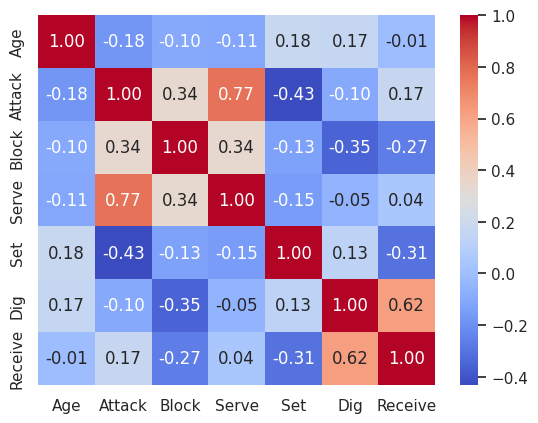

In [11]:
sns.set(style="darkgrid", font_scale=1)
sns.heatmap(df[columnas_numericas].corr().round(3), annot=True, fmt=".2f", cmap="coolwarm")



# Matriz de correlaciones completa
print("=== Matriz de correlaciones (variables numéricas) ===")
df[columnas_numericas].corr().round(3)



### Interpretación:

Este análisis se enfocará en las variables que si están fuertemente relacionadas (corr >= 0.5)

- __Serve/Attack (corr 0.77)__: Ya que al
- __Dig/Receive (corr 0.62)__: Y esta tambien es alta ya que __"dig" (Defensa)__ son las veces que el jugador rescata el valon después de un ataque, puede ser servicio u otro tipo de ataque del equipo contrario y __"receive" (Recepcion)__ son las veces que un jugador recivio con extio un saque del equipo contrario.





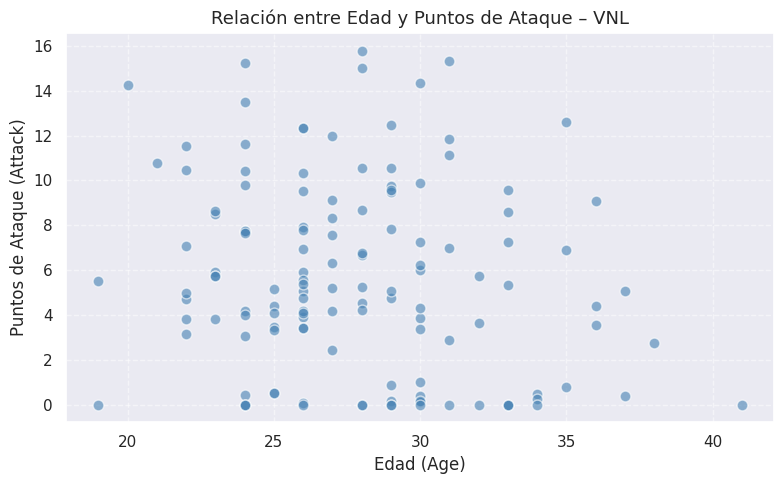

Correlación de Pearson r = -0.1778494434659239


In [12]:
# Gráfico de dispersión: Age vs Dig
plt.figure(figsize=(8, 5))
plt.scatter(df["Age"], df["Attack"], color="steelblue", alpha=0.6, edgecolors="white", s=60)
plt.xlabel("Edad (Age)", fontsize=12)
plt.ylabel("Puntos de Ataque (Attack)", fontsize=12)
plt.title("Relación entre Edad y Puntos de Ataque – VNL", fontsize=13)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()
print(f"Correlación de Pearson r = {correlacion}")

### Interpretación

Siguiendo con el analis de correlación entre Age y Attack, se puede observar que los datos estan bastante dispersos, pero en esta grafica podemos apreciar que la mayoría de jugadores se concentran en una edad de 25 a 35 años.

### 2.2 Construcción del Modelo

- **Variable independiente (X):** `Age` – la edad del jugador.
- **Variable dependiente (y):** `Dig` – promedio de defensas exitosas por set.

Dividimos los datos en **80% entrenamiento** y **20% prueba**.

In [13]:
# Definir variables
X = df[["Age"]]        # Variable independiente (debe ser 2D para sklearn)
y = df["Dig"]          # Variable dependiente

# Dividir en conjunto de entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("=== División del dataset ===")
print(f"  Total de registros  : {len(df)}")
print(f"  Entrenamiento (80%) : {len(X_train)} registros")
print(f"  Prueba        (20%) : {len(X_test)} registros")

=== División del dataset ===
  Total de registros  : 131
  Entrenamiento (80%) : 104 registros
  Prueba        (20%) : 27 registros


### 2.3 Entrenamiento y Predicción

Entrenamos el modelo de con los datos de entrenamiento y luego hacemos predicciones sobre los datos de prueba.

In [21]:
# Crear y entrenar el modelo
modelo = LinearRegression()
modelo.fit(X_train, y_train)

# Parámetros del modelo
print("PARAMETROS DEL MODELO")
print(f"Intercepto  (b0): {modelo.intercept_:.4f}")
print(f"Pendiente   (b1): {modelo.coef_[0]:.4f}")
print()
print(f"Ecuación del modelo:")
print(f"Dig = {modelo.intercept_:.4f} + ({modelo.coef_[0]:.4f}) × Age")

PARAMETROS DEL MODELO
Intercepto  (b0): 1.2734
Pendiente   (b1): 0.0788

Ecuación del modelo:
Dig = 1.2734 + (0.0788) × Age


In [15]:
y_pred = modelo.predict(X_test)

comparacion = pd.DataFrame({
    "Age": X_test["Age"].values,
    "Dig Real": y_test.values,
    "Dig Predicho": y_pred.round(2),
    "Error": (y_test.values - y_pred).round(2)
}).reset_index(drop=True)

print("=== Comparación: Valores Reales vs Predichos (primeros 10) ===")
comparacion.head(10)

=== Comparación: Valores Reales vs Predichos (primeros 10) ===


,Age,Dig Real,Dig Predicho,Error
0,27,1.78,3.40,-1.62
1,30,2.07,3.64,-1.57
2,27,2.31,3.40,-1.09
3,27,3.17,3.40,-0.23
4,29,8.73,3.56,5.17
5,26,2.17,3.32,-1.15
6,29,2.00,3.56,-1.56
7,30,3.00,3.64,-0.64
8,22,1.47,3.01,-1.54
9,30,1.91,3.64,-1.73


/home/emilianux/DataspellProjects/Ciencia-de-datos/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


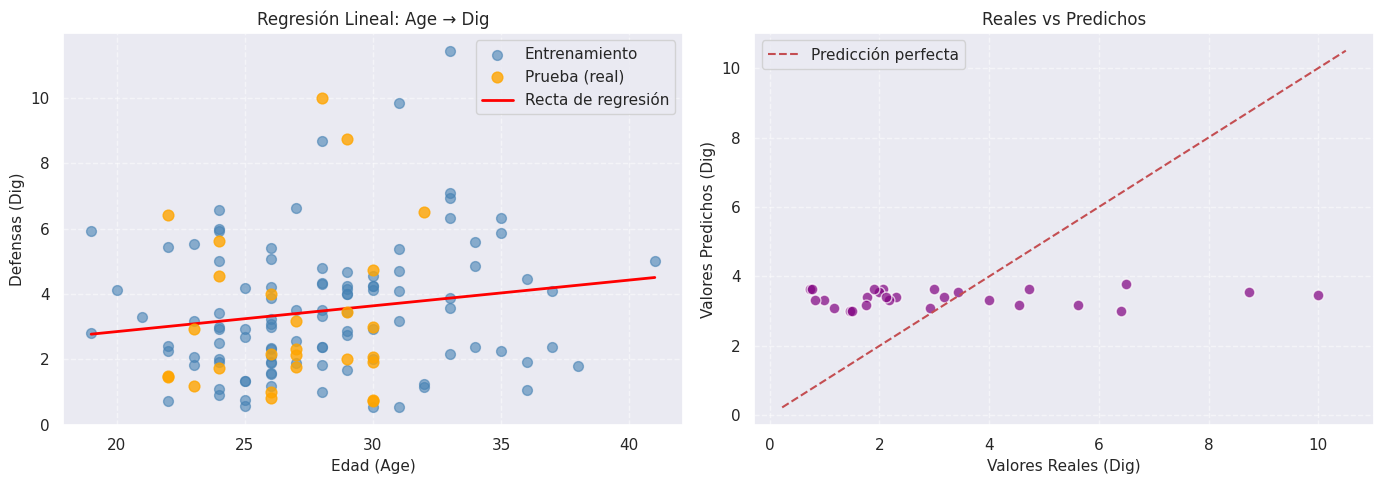

In [16]:
# Gráfico de la recta de regresión sobre los datos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Gráfico 1: Recta de regresión ---
ax1 = axes[0]
ax1.scatter(X_train, y_train, color="steelblue", alpha=0.6, label="Entrenamiento", s=50)
ax1.scatter(X_test, y_test, color="orange", alpha=0.8, label="Prueba (real)", s=60, zorder=5)

x_line = np.linspace(df["Age"].min(), df["Age"].max(), 100).reshape(-1, 1)
y_line = modelo.predict(x_line)
ax1.plot(x_line, y_line, color="red", linewidth=2, label="Recta de regresión")

ax1.set_xlabel("Edad (Age)", fontsize=11)
ax1.set_ylabel("Defensas (Dig)", fontsize=11)
ax1.set_title("Regresión Lineal: Age → Dig", fontsize=12)
ax1.legend()
ax1.grid(True, linestyle="--", alpha=0.5)

# --- Gráfico 2: Reales vs Predichos ---
ax2 = axes[1]
ax2.scatter(y_test, y_pred, color="purple", alpha=0.7, edgecolors="white", s=60)
lim_min = min(y_test.min(), y_pred.min()) - 0.5
lim_max = max(y_test.max(), y_pred.max()) + 0.5
ax2.plot([lim_min, lim_max], [lim_min, lim_max], "r--", linewidth=1.5, label="Predicción perfecta")
ax2.set_xlabel("Valores Reales (Dig)", fontsize=11)
ax2.set_ylabel("Valores Predichos (Dig)", fontsize=11)
ax2.set_title("Reales vs Predichos", fontsize=12)
ax2.legend()
ax2.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

### 2.4 Evaluación del Modelo

Calculamos tres métricas de error para evaluar qué tan buenas son las predicciones:

| Métrica | Significado |
|---------|-------------|
| **MAE** (Error Absoluto Medio) | Promedio del error en las mismas unidades que Dig |
| **RMSE** (Raíz del Error Cuadrático Medio) | Penaliza más los errores grandes |
| **R²** (Coeficiente de determinación) | Qué porcentaje de la variación de Dig explica el modelo (0–1) |

In [17]:
# Cálculo de métricas
mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print("=== Métricas de evaluación del modelo ===")
print(f"  MAE  (Error Absoluto Medio)          : {mae:.4f}")
print(f"  MSE  (Error Cuadrático Medio)        : {mse:.4f}")
print(f"  RMSE (Raíz del Error Cuadrático)     : {rmse:.4f}")
print(f"  R²   (Coeficiente de determinación)  : {r2:.4f} ({r2*100:.1f}%)")
print()
print("Interpretación:")
print(f"  El modelo se equivoca en promedio {mae:.2f} defensas por set (MAE).")
print(f"  El modelo explica el {r2*100:.1f}% de la variación en las defensas (R²).")

=== Métricas de evaluación del modelo ===
  MAE  (Error Absoluto Medio)          : 1.9070
  MSE  (Error Cuadrático Medio)        : 5.6072
  RMSE (Raíz del Error Cuadrático)     : 2.3679
  R²   (Coeficiente de determinación)  : 0.0088 (0.9%)

Interpretación:
  El modelo se equivoca en promedio 1.91 defensas por set (MAE).
  El modelo explica el 0.9% de la variación en las defensas (R²).


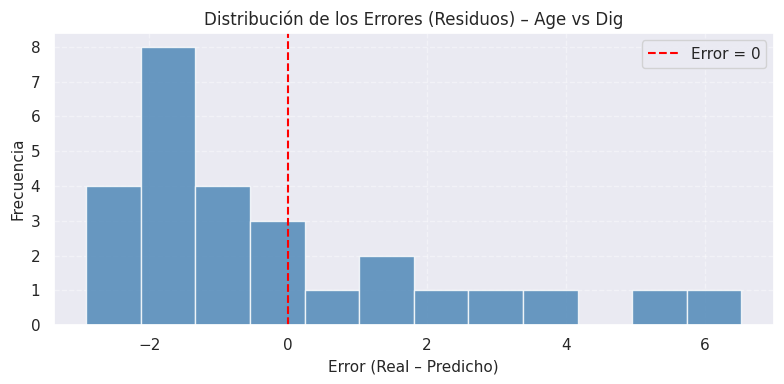

Un histograma centrado en 0 indica que el modelo no tiene sesgo sistemático.


In [18]:
# Distribución de los errores (residuos)
residuos = y_test.values - y_pred

plt.figure(figsize=(8, 4))
plt.hist(residuos, bins=12, color="steelblue", edgecolor="white", alpha=0.8)
plt.axvline(0, color="red", linestyle="--", linewidth=1.5, label="Error = 0")
plt.xlabel("Error (Real – Predicho)", fontsize=11)
plt.ylabel("Frecuencia", fontsize=11)
plt.title("Distribución de los Errores (Residuos) – Age vs Dig", fontsize=12)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()
print("Un histograma centrado en 0 indica que el modelo no tiene sesgo sistemático.")

### 2.5 Conclusión

A continuación se presenta una reflexión sobre los resultados obtenidos en este análisis.

In [19]:
# Resumen final
print("=" * 55)
print("       RESUMEN FINAL DEL MODELO – VNL")
print("=" * 55)
print(f"Variable independiente (X) : Age (Edad)")
print(f"Variable dependiente   (y) : Dig (Defensas por set)")
print(f"Correlación de Pearson (r) : {correlacion:.4f}")
print(f"Ecuación del modelo        : Dig = {modelo.intercept_:.2f} + {modelo.coef_[0]:.4f} × Age")
print(f"MAE                        : {mae:.4f}")
print(f"RMSE                       : {rmse:.4f}")
print(f"R²                         : {r2:.4f} ({r2*100:.1f}%)")
print("=" * 55)

       RESUMEN FINAL DEL MODELO – VNL
Variable independiente (X) : Age (Edad)
Variable dependiente   (y) : Dig (Defensas por set)
Correlación de Pearson (r) : -0.1778
Ecuación del modelo        : Dig = 1.27 + 0.0788 × Age
MAE                        : 1.9070
RMSE                       : 2.3679
R²                         : 0.0088 (0.9%)


#### Reflexión sobre los resultados

**Sobre la correlación:**  
La correlación de Pearson entre la edad y las defensas (Dig) resultó ser débil y positiva (r = 0.1671). El valor p (0.0564) es ligeramente mayor a 0.05, lo que indica que esta correlación **no es estadísticamente significativa**. Esto sugiere que la edad no es un factor determinante para predecir cuántas defensas realiza un jugador por set.

**Sobre el modelo:**  
La ecuación obtenida fue: **Dig = 1.2734 + 0.0788 × Age**. Aunque la pendiente es positiva (a mayor edad, ligeramente más defensas), el R² de apenas 0.88% confirma que el modelo prácticamente **no explica la variación** en las defensas. El MAE de 1.91 y el RMSE de 2.37 indican que los errores de predicción son considerables en relación al rango de valores de Dig en el dataset.

**Sobre su aplicabilidad:**  
Este resultado tiene sentido desde el punto de vista del voleibol: el número de defensas de un jugador depende principalmente de su **posición en la cancha**. Los Liberos (L) y los Outside Hitters (OH) naturalmente realizan más defensas que un Central (MB) o un Armador (S), independientemente de su edad. Por eso la edad sola no es un buen predictor.

**Recomendación:**  
Para mejorar el modelo, se sugiere incorporar la **posición** como variable adicional (regresión múltiple) o construir modelos separados por posición, donde la relación entre variables estadísticas sería mucho más clara y precisa.